In [1]:
import os 
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from dotenv import load_dotenv

from config.paths import (
    MULTIMODEL_DIR 
)

MULTIMODEL_DATASET = MULTIMODEL_DIR / "multimodel_dataset.csv"

In [3]:
df= pd.read_csv(MULTIMODEL_DATASET, low_memory=False)

print("CINEFUSION-X :::: Master Dataset")

print("Shape:", df.shape)

CINEFUSION-X :::: Master Dataset
Shape: (88181, 23)


In [4]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

Number of rows: 88181
Number of columns: 23


In [5]:
df.dtypes

imdb_id                     str
release_year              int64
rating                  float64
num_votes                 int64
tmdb_id                   int64
title                       str
original_title              str
overview                    str
tagline                     str
poster_path                 str
poster_file                 str
budget                    int64
revenue                   int64
runtime                   int64
popularity              float64
release_date                str
original_language           str
vote_average            float64
vote_count                int64
genres                      str
production_companies        str
production_countries        str
spoken_languages            str
dtype: object

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 88181 entries, 0 to 88180
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   imdb_id               88181 non-null  str    
 1   release_year          88181 non-null  int64  
 2   rating                88181 non-null  float64
 3   num_votes             88181 non-null  int64  
 4   tmdb_id               88181 non-null  int64  
 5   title                 88181 non-null  str    
 6   original_title        88181 non-null  str    
 7   overview              87956 non-null  str    
 8   tagline               44905 non-null  str    
 9   poster_path           88181 non-null  str    
 10  poster_file           88181 non-null  str    
 11  budget                88181 non-null  int64  
 12  revenue               88181 non-null  int64  
 13  runtime               88181 non-null  int64  
 14  popularity            88181 non-null  float64
 15  release_date          88136 no

In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
print("imdb_id" in df.columns)

True


In [9]:
print("Missing IMDb IDs:", df["imdb_id"].isna().sum())
print("Unique IMDb IDs:", df["imdb_id"].nunique())
print("Duplicate IMDb IDs:", df["imdb_id"].duplicated().sum())

Missing IMDb IDs: 0
Unique IMDb IDs: 88181
Duplicate IMDb IDs: 0


In [10]:
missing = df.isna().sum()

missing = missing.sort_values(ascending=False)

missing

tagline                 43276
production_companies     9147
production_countries     3580
spoken_languages         1723
genres                    590
overview                  225
release_date               45
original_title              0
title                       0
tmdb_id                     0
num_votes                   0
rating                      0
release_year                0
imdb_id                     0
poster_path                 0
popularity                  0
runtime                     0
revenue                     0
budget                      0
poster_file                 0
vote_count                  0
original_language           0
vote_average                0
dtype: int64

In [28]:
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing_percent[missing_percent > 0]

tagline                 49.076332
production_companies    10.372983
production_countries     4.059831
spoken_languages         1.953936
genres                   0.669078
overview                 0.255157
release_date             0.051031
dtype: float64

In [12]:
missing_table = pd.DataFrame({
    "Missing": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2)
})

missing_table = missing_table[
    missing_table["Missing"] > 0
].sort_values("Missing", ascending= False)

missing_table

,Missing,Missing %
tagline,43276,49.08
production_companies,9147,10.37
production_countries,3580,4.06
spoken_languages,1723,1.95
genres,590,0.67
overview,225,0.26
release_date,45,0.05


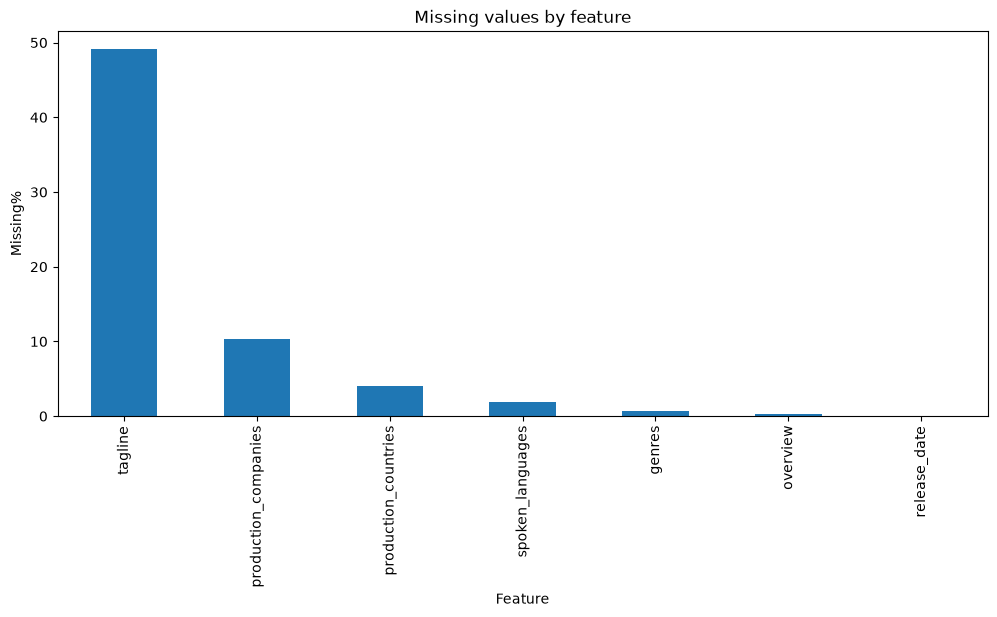

In [35]:
missing_table["Missing %"].plot(
    kind = "bar",
    figsize = (12,5)
)

plt.title("Missing values by feature")
plt.ylabel("Missing%")
plt.xlabel("Feature")
plt.xticks(rotation=90)
plt.show()

In [36]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

numeric_cols

['release_year',
 'rating',
 'num_votes',
 'tmdb_id',
 'budget',
 'revenue',
 'runtime',
 'popularity',
 'vote_average',
 'vote_count']

In [38]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols

['release_year',
 'rating',
 'num_votes',
 'tmdb_id',
 'budget',
 'revenue',
 'runtime',
 'popularity',
 'vote_average',
 'vote_count']

In [39]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
release_year,88181.0,1.999950e+03,2.403655e+01,1897.0,1988.0000,2009.0000,2018.0000,2.026000e+03
rating,88181.0,5.998906e+00,1.239357e+00,1.0,5.3000,6.2000,6.9000,9.600000e+00
num_votes,88181.0,1.431864e+04,7.405788e+04,300.0,542.0000,1177.0000,3869.0000,3.204686e+06
tmdb_id,88181.0,3.295685e+05,3.752806e+05,2.0,47489.0000,154066.0000,501953.0000,1.744543e+06
budget,88181.0,3.483496e+06,1.654272e+07,0.0,0.0000,0.0000,0.0000,7.000000e+08
revenue,88181.0,9.207938e+06,6.106397e+07,0.0,0.0000,0.0000,0.0000,2.923706e+09
runtime,88181.0,1.008931e+02,2.604066e+01,0.0,89.0000,97.0000,110.0000,1.440000e+03
popularity,88181.0,2.065808e+00,5.356043e+00,0.0,0.8836,1.2558,1.9719,5.208023e+02
vote_average,88181.0,5.884623e+00,1.349183e+00,0.0,5.2670,6.0760,6.7500,1.000000e+01
vote_count,88181.0,2.903277e+02,1.338451e+03,0.0,12.0000,27.0000,92.0000,4.061100e+04


In [40]:
for col in numeric_cols:
    zero = (df[col] == 0).sum()
    negative = (df[col] < 0).sum()

    if zero > 0 or negative > 0:
        print(
            f"{col}: "
            f"zero = {zero}, "
            f"negative = {negative}"
        )

budget: zero = 70187, negative = 0
revenue: zero = 69177, negative = 0
runtime: zero = 1015, negative = 0
popularity: zero = 13, negative = 0
vote_average: zero = 1250, negative = 0
vote_count: zero = 1250, negative = 0


In [42]:
import pandas as pd 

dif = pd.read_csv("../data/processed/multimodel_data/multimodel_dataset_enriched.csv")

In [43]:
dif.columns.tolist()

['imdb_id',
 'release_year',
 'rating',
 'num_votes',
 'tmdb_id',
 'title',
 'original_title',
 'overview',
 'tagline',
 'poster_path',
 'poster_file',
 'budget',
 'revenue',
 'runtime',
 'popularity',
 'release_date',
 'original_language',
 'vote_average',
 'vote_count',
 'genres',
 'production_companies',
 'production_countries',
 'spoken_languages',
 'budget_sources',
 'revenue_sources',
 'source_files',
 'budget_final',
 'revenue_final']

In [44]:
common = df.columns.intersection(dif.columns).tolist()

In [48]:
dif[["budget", "budget_final"]].head()

,budget,budget_final
0,25000000.0,25000000.0
1,185000000.0,185000000.0
2,160000000.0,160000000.0
3,63000000.0,63000000.0
4,165000000.0,165000000.0


In [8]:
df.loc[df["production_countries"] == "India"]

,imdb_id,release_year,rating,num_votes,tmdb_id,title,original_title,overview,tagline,poster_path,...,runtime,popularity,release_date,original_language,vote_average,vote_count,genres,production_companies,production_countries,spoken_languages
291,tt10811166,2022,8.5,579328,900783,The Kashmir Files,द कश्मीर फ़ाइल्स,"Based on a true tragedy, the emotionally trigg...",Right to Justice,/2VvjJFDBFYkVgr89BjqbUl26QyW.jpg,...,170,1.9646,2022-03-11,hi,7.134,101,History|Drama,Abhishek Agarwal Arts|Zee Studios,India,Hindi
404,tt1187043,2009,8.4,485154,20453,3 Idiots,3 Idiots,Rascal. Joker. Dreamer. Genius... You've never...,Aal Izz Well!,/66A9MqXOyVFCssoloscw79z8Tew.jpg,...,171,13.8814,2009-12-23,hi,8.005,2778,Drama|Comedy,Vidhu Vinod Chopra Productions|Vinod Chopra Films,India,English|Hindi
1061,tt5074352,2016,8.3,245244,360814,Dangal,दंगल,Dangal is an extraordinary true story based on...,NaN,/cJRPOLEexI7qp2DKtFfCh7YaaUG.jpg,...,161,5.4197,2016-12-21,hi,7.874,1186,Drama|Family|Comedy,Aamir Khan Productions|UTV Motion Pictures|Dis...,India,Hindi
1111,tt15097216,2021,8.6,235071,855400,Jai Bhim,ஜெய் பீம்,A pregnant woman from a primitive tribal commu...,NaN,/ehybiOtBUtrMkmtB39zQEtq1Jie.jpg,...,164,1.6397,2021-11-02,ta,7.335,240,Crime|Drama|Mystery|History,2D Entertainment,India,Tamil
1119,tt0986264,2007,8.3,233869,7508,Like Stars on Earth,तारे ज़मीन पर,Ishaan Awasthi is an eight-year-old whose worl...,Every child is special.,/puHRt6Raovm5ujGCdwLWvRv4NHU.jpg,...,162,5.8548,2007-12-21,hi,7.983,1376,Drama,Aamir Khan Productions|PVR Inox Pictures|UTV M...,India,Hindi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88058,tt1603862,2009,4.5,300,20292,Jashnn: The Music Within,Jashnn,Jashnn Music Within,The Music Within,/3xpVu5esYvlyy1IUuRZalvnCnEl.jpg,...,127,0.8547,2009-07-17,hi,6.700,3,Drama|Music|Romance,NaN,India,Hindi
88097,tt8810990,2019,4.9,300,677285,Kiss,Kiss,Kiss tells the love story of Nandini and Arjun...,NaN,/vp2mQynmTY0XTwOpoQnubtH9rDp.jpg,...,148,0.8994,2019-09-27,kn,2.600,4,Romance|Comedy,NaN,India,Kannada
88100,tt15360418,2022,5.1,300,982447,Dongalunnaru Jagratha,దొంగలున్నారు జాగ్రత్త,Raju a small time thief breaks into a customiz...,NaN,/g0YqbcgM14hRJPLdIfLXQjunyRk.jpg,...,96,1.5279,2022-09-23,te,4.700,3,Thriller,Suresh Productions|Guru Films,India,Telugu
88109,tt0156258,1974,7.3,300,304658,Aavishkar,आविष्कार,Amar and Mansi live a rather peaceful and happ...,NaN,/14WXemlgE5ieWU5mBD8NwlkakxM.jpg,...,108,0.7199,1974-06-14,hi,8.000,1,Drama|Romance,NaN,India,Hindi


In [7]:
df["production_countries"].unique

<bound method Series.unique of 0                       United States of America
1        United Kingdom|United States of America
2        United Kingdom|United States of America
3               Germany|United States of America
4        United Kingdom|United States of America
                          ...                   
88176                            Belgium|Germany
88177                    Czech Republic|Slovakia
88178                                      India
88179                                    Romania
88180                   United States of America
Name: production_countries, Length: 88181, dtype: str>